# Student Performance Analysis

Using Python (Pandas, NumPy, Matplotlib)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Load Dataset

In [11]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Task 2: Data Preprocessing
- Identifying missing values
- Cleaning inconsistent data
- Converting formats


In [12]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [13]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

C:\Users\deboj\AppData\Local\Temp\ipykernel_11260\3456872822.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [14]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

## Task 3: Data Analysis

- Average marks per subject
-  Highest and lowest scoring students
-  Overall class performance summary

In [15]:
average_marks = df[['math score', 'reading score', 'writing score']].mean()
average_marks

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

In [16]:
df['total'] = df[['math score', 'reading score', 'writing score']].sum(axis=1)

highest = df.loc[df['total'].idxmax()]
lowest = df.loc[df['total'].idxmin()]

print("Highest Scoring Student:\n", highest)
print("\nLowest Scoring Student:\n", lowest)

Highest Scoring Student:
 gender                                    female
race/ethnicity                           group e
parental level of education    bachelor's degree
lunch                                   standard
test preparation course                     none
math score                                   100
reading score                                100
writing score                                100
total                                        300
Name: 458, dtype: object

Lowest Scoring Student:
 gender                                   female
race/ethnicity                          group c
parental level of education    some high school
lunch                              free/reduced
test preparation course                    none
math score                                    0
reading score                                17
writing score                                10
total                                        27
Name: 59, dtype: object


In [17]:
df[['math score', 'reading score', 'writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Task 4: Students Below Threshold

In [18]:
def students_below_threshold(data, threshold):
    if 'total' not in data.columns:
        data['total'] = data[['math score', 'reading score', 'writing score']].sum(axis=1)
    
    return data[data['total'] < threshold]

In [19]:
students_below_threshold(df, 150)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total
3,male,group a,associate's degree,free/reduced,none,47,57,44,148
7,male,group b,some college,free/reduced,none,40,43,39,122
9,female,group b,high school,free/reduced,none,38,60,50,148
11,male,group d,associate's degree,standard,none,40,52,43,135
17,female,group b,some high school,free/reduced,none,18,32,28,78
...,...,...,...,...,...,...,...,...,...
921,female,group c,high school,free/reduced,none,35,53,46,134
928,male,group e,associate's degree,free/reduced,completed,46,43,44,133
978,male,group d,high school,standard,completed,55,41,48,144
980,female,group b,high school,free/reduced,none,8,24,23,55


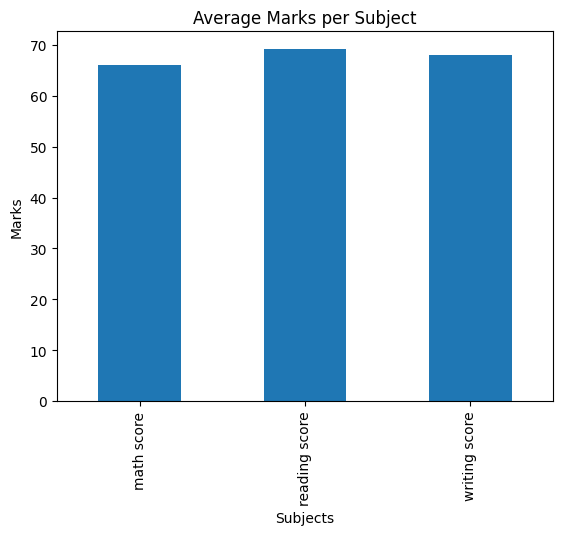

In [ ]:
average_marks.plot(kind='bar')
plt.title("Average Marks per Subject")
plt.xlabel("Subjects")
plt.ylabel("Marks")
plt.show()

## Conclusion

The analysis helps understand student performance, identify top performers, and detect students needing academic support.